## Enteric Fermentation Factor

Source: 2024 UGANDA’S SECOND BIENNIAL UPDATE REPORT TO THE UNITED NATIONS FRAMEWORK CONVENTION ON CLIMATE CHANGE Table 2-1: Tier 1 enhanced livestock characterisation and application of Emission Factors

In [1]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Set up paths
CURRENT_DIR_PATH = os.getcwd()
OUTPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "output_data")
INPUT_DATA_DIR_PATH = os.path.join(CURRENT_DIR_PATH, "input_data")
LVST_DATA_DIR_PATH = os.path.join(INPUT_DATA_DIR_PATH, "lvst")
# GROWTH_RATES_DATA_DIR_PATH = os.path.join(INPUT_DATA_DIR_PATH, "fernando_ndpiv")

In [3]:
# Load original uganda data
uga_legacy_df = pd.read_csv(os.path.join(INPUT_DATA_DIR_PATH, "sisepuede_raw_global_inputs_uganda.csv"))
uga_legacy_df.head()

,year,frac_lvst_mm_buffalo_anaerobic_digester,frac_lvst_mm_cattle_dairy_anaerobic_digester,frac_lvst_mm_cattle_nondairy_anaerobic_digester,frac_lvst_mm_chickens_anaerobic_digester,frac_lvst_mm_goats_anaerobic_digester,frac_lvst_mm_horses_anaerobic_digester,frac_lvst_mm_mules_anaerobic_digester,frac_lvst_mm_pigs_anaerobic_digester,frac_lvst_mm_sheep_anaerobic_digester,...,nemomod_entc_frac_min_share_production_pp_biogas,nemomod_entc_frac_min_share_production_pp_coal,nemomod_entc_frac_min_share_production_pp_coal_ccs,nemomod_entc_frac_min_share_production_pp_gas,nemomod_entc_frac_min_share_production_pp_gas_ccs,nemomod_entc_frac_min_share_production_pp_geothermal,nemomod_entc_frac_min_share_production_pp_nuclear,nemomod_entc_frac_min_share_production_pp_ocean,nemomod_entc_frac_min_share_production_pp_waste_incineration,nemomod_entc_frac_min_share_production_pp_wind
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
ef_lvst_entferm_legacy_df = uga_legacy_df[[col for col in uga_legacy_df.columns if "ef_lvst_entferm" in col]]
ef_lvst_entferm_legacy_df

,ef_lvst_entferm_cattle_dairy_kg_ch4_head,ef_lvst_entferm_horses_kg_ch4_head,ef_lvst_entferm_buffalo_kg_ch4_head,ef_lvst_entferm_mules_kg_ch4_head,ef_lvst_entferm_pigs_kg_ch4_head,ef_lvst_entferm_sheep_kg_ch4_head,ef_lvst_entferm_goats_kg_ch4_head,ef_lvst_entferm_chickens_kg_ch4_head,ef_lvst_entferm_cattle_nondairy_kg_ch4_head
0,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
1,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
2,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
3,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
4,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
...,...,...,...,...,...,...,...,...,...
81,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
82,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
83,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0
84,87.0,18.0,68.0,10.0,1.25,7.0,7.0,0.0,56.0


In [5]:
uga_new_entferm_factors_df = pd.read_csv(os.path.join(LVST_DATA_DIR_PATH, "uganda_enteric_fermentation_emission_factors.csv"))
uga_new_entferm_factors_df

,lvst_category,system,emission_factor_kg_ch4_head
0,cattle_dairy,dairy cows,76.0
1,cattle_nondairy,multiple breeds,52.0
2,goats,high production system,9.0
3,goats,low production system,5.0
4,sheep,high production system,9.0
5,sheep,low production system,5.0
6,pigs,high production system,1.5
7,pigs,low production system,1.0
8,horses,NaN,0.0
9,buffalo,NaN,0.0


### Compute means and pivot table

In [6]:
new_factors_grouped_df = uga_new_entferm_factors_df.groupby("lvst_category")["emission_factor_kg_ch4_head"].mean().reset_index()
new_factors_grouped_df

,lvst_category,emission_factor_kg_ch4_head
0,buffalo,0.00
1,cattle_dairy,76.00
2,cattle_nondairy,52.00
3,chickens,0.00
4,goats,7.00
5,horses,0.00
6,mules,0.00
7,pigs,1.25
8,sheep,7.00


In [7]:
# add year col
new_factors_grouped_df["year"] = 2018
new_factors_grouped_df

,lvst_category,emission_factor_kg_ch4_head,year
0,buffalo,0.00,2018
1,cattle_dairy,76.00,2018
2,cattle_nondairy,52.00,2018
3,chickens,0.00,2018
4,goats,7.00,2018
5,horses,0.00,2018
6,mules,0.00,2018
7,pigs,1.25,2018
8,sheep,7.00,2018


In [8]:
new_factors_pivot_df = new_factors_grouped_df.pivot(index="year", columns="lvst_category", values="emission_factor_kg_ch4_head").reset_index()
new_factors_pivot_df.columns.name = None
new_factors_pivot_df

,year,buffalo,cattle_dairy,cattle_nondairy,chickens,goats,horses,mules,pigs,sheep
0,2018,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0


In [10]:
# rename columns to match legacy df
for col in new_factors_pivot_df.columns:
    if col != "year":
        new_factors_pivot_df = new_factors_pivot_df.rename(columns={col: f"ef_lvst_entferm_{col.replace(' ', '_').lower()}_kg_ch4_head"})

new_factors_pivot_df

,year,ef_lvst_entferm_buffalo_kg_ch4_head,ef_lvst_entferm_cattle_dairy_kg_ch4_head,ef_lvst_entferm_cattle_nondairy_kg_ch4_head,ef_lvst_entferm_chickens_kg_ch4_head,ef_lvst_entferm_goats_kg_ch4_head,ef_lvst_entferm_horses_kg_ch4_head,ef_lvst_entferm_mules_kg_ch4_head,ef_lvst_entferm_pigs_kg_ch4_head,ef_lvst_entferm_sheep_kg_ch4_head
0,2018,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0


In [11]:
# Copy rows until 2100
years_to_add = list(range(2019, 2101))
new_factors_full_df = pd.concat([new_factors_pivot_df]*len(years_to_add), ignore_index=True)
new_factors_full_df["year"] = years_to_add
new_factors_full_df

,year,ef_lvst_entferm_buffalo_kg_ch4_head,ef_lvst_entferm_cattle_dairy_kg_ch4_head,ef_lvst_entferm_cattle_nondairy_kg_ch4_head,ef_lvst_entferm_chickens_kg_ch4_head,ef_lvst_entferm_goats_kg_ch4_head,ef_lvst_entferm_horses_kg_ch4_head,ef_lvst_entferm_mules_kg_ch4_head,ef_lvst_entferm_pigs_kg_ch4_head,ef_lvst_entferm_sheep_kg_ch4_head
0,2019,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
1,2020,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
2,2021,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
3,2022,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
4,2023,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
...,...,...,...,...,...,...,...,...,...,...
77,2096,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
78,2097,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
79,2098,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0
80,2099,0.0,76.0,52.0,0.0,7.0,0.0,0.0,1.25,7.0


### Validation

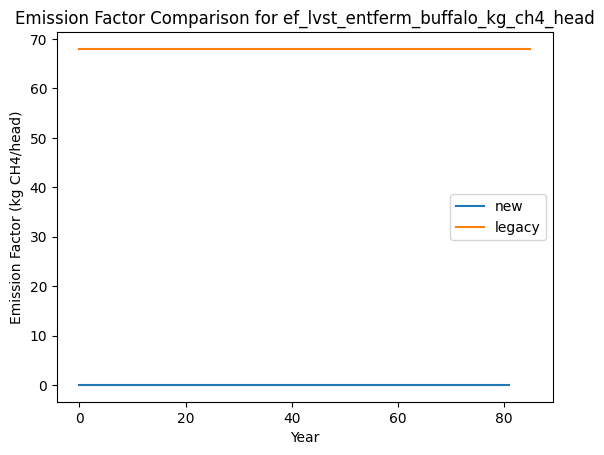

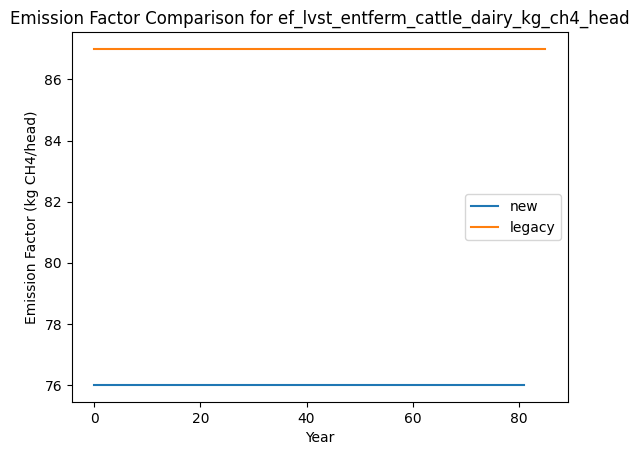

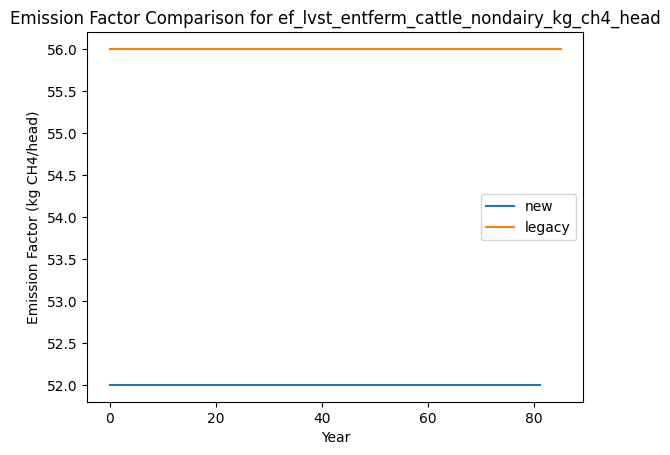

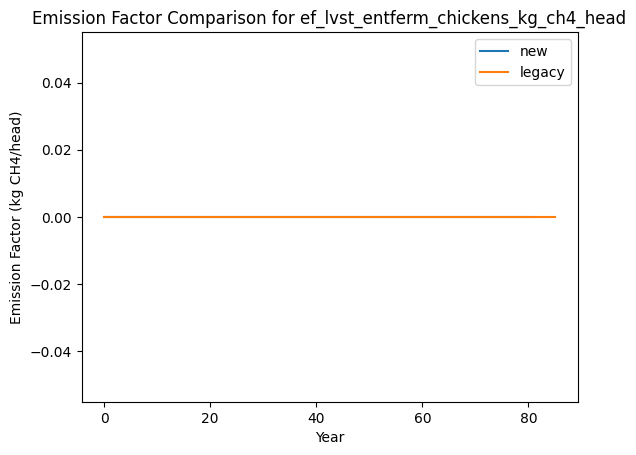

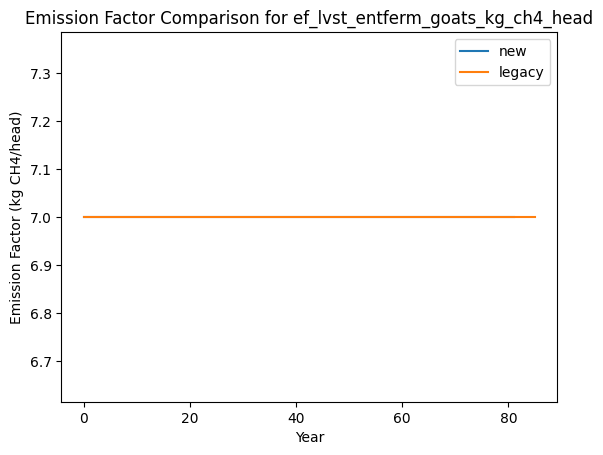

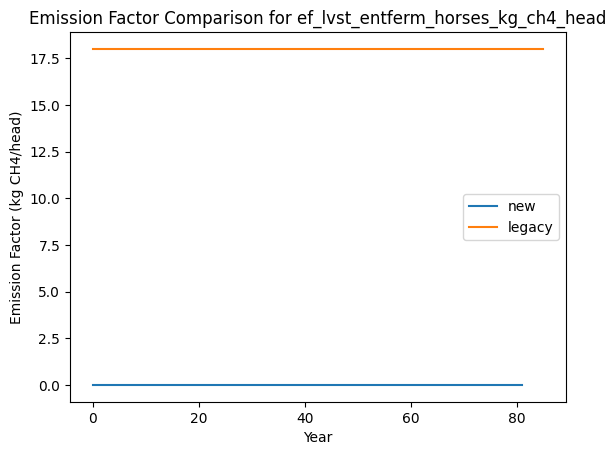

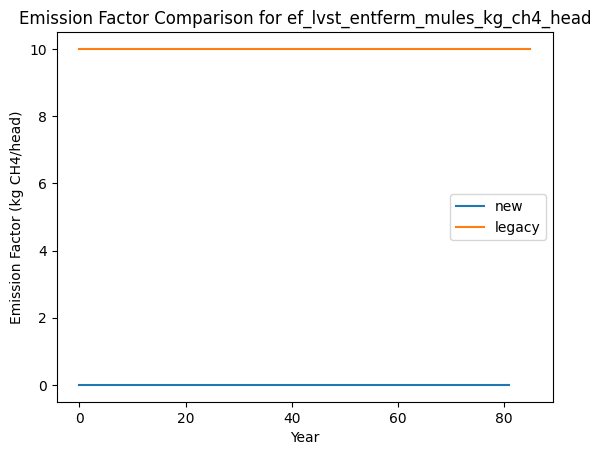

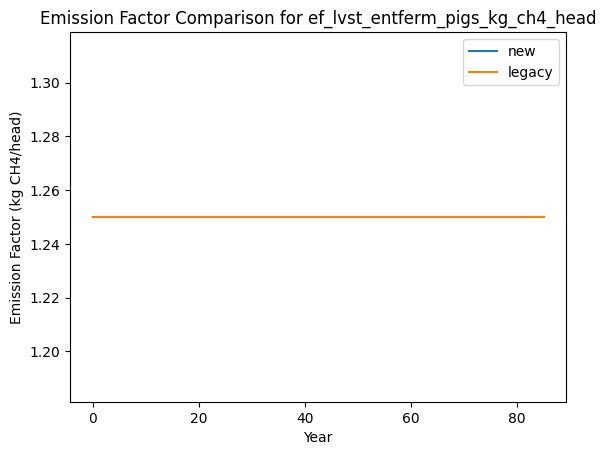

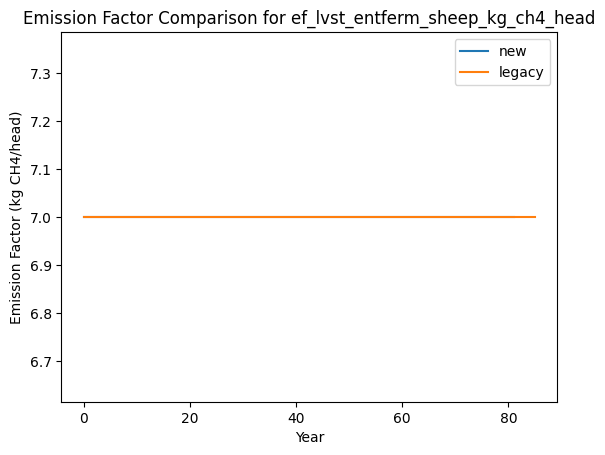

In [12]:
for col in new_factors_full_df.columns:
    if col != "year":
        plt.plot(new_factors_full_df[col], label="new")
        plt.plot(ef_lvst_entferm_legacy_df[col], label="legacy")
        plt.xlabel("Year")
        plt.ylabel("Emission Factor (kg CH4/head)")
        plt.title(f"Emission Factor Comparison for {col}")
        plt.legend()
        plt.show()

In [13]:
# Save to output dir
new_factors_full_df.to_csv(os.path.join(OUTPUT_DATA_DIR_PATH, "ef_lvst_entferm_kg_ch4_head.csv"), index=False)